In [1]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;
import seaborn as sns;

In [2]:
production = pd.read_csv("production_events.csv")
quality = pd.read_csv("quality_inspection.csv")
sensor = pd.read_csv("sensor_readings.csv")
supplier = pd.read_csv("supplier_master.csv")
bom = pd.read_csv("bom_master.csv")
workorder = pd.read_csv("work_orders.csv")
tool = pd.read_csv("tool_master.csv")
calibration = pd.read_csv("calibration_master.csv")
operator = pd.read_csv("operator_master.csv")
warranty = pd.read_csv("warranty_claims.csv")

# Test Case 1

In [3]:
print("Production:", production.columns)
print("Quality:", quality.columns)
print("Sensor:", sensor.columns)
print("Supplier:", supplier.columns)
print("BOM:", bom.columns)
print("Work Order:", workorder.columns)
print("Tool:", tool.columns)
print("Calibration:", calibration.columns)
print("Operator:", operator.columns)
print("Warranty:", warranty.columns)

Production: Index(['Event_ID', 'VIN', 'Work_Order', 'Model', 'Line', 'Station',
       'Timestamp', 'Part_Number', 'Supplier_Code', 'Operator_ID', 'Tool_ID',
       'Shift', 'BOM_Status', 'Machine_ID', 'Planned_Time_Minutes',
       'Run_Time_Minutes', 'Downtime_Minutes', 'Ideal_Cycle_Time',
       'Total_Units', 'Reject_Units', 'Good_Units'],
      dtype='object')
Quality: Index(['Inspection_ID', 'Event_ID', 'VIN', 'Defect_Code', 'Defect',
       'Inspection_Source', 'Inspector_ID', 'Rework_Flag', 'Scrap_Reason',
       'Result'],
      dtype='object')
Sensor: Index(['Reading_ID', 'Event_ID', 'Sensor_ID', 'Timestamp', 'Torque',
       'Temperature', 'Pressure', 'Vibration_mm_s', 'Energy_kWh',
       'Calibration_Factor'],
      dtype='object')
Supplier: Index(['Supplier_Code', 'Supplier_Name', 'City', 'State', 'Country',
       'Supplier_Type', 'Quality_Rating', 'On_Time_Delivery_%', 'PPM_Defects',
       'Contact_Email'],
      dtype='object')
BOM: Index(['Part_Number', 'Part_Name', 

In [4]:
production.head(10)

,Event_ID,VIN,Work_Order,Model,Line,Station,Timestamp,Part_Number,Supplier_Code,Operator_ID,...,Shift,BOM_Status,Machine_ID,Planned_Time_Minutes,Run_Time_Minutes,Downtime_Minutes,Ideal_Cycle_Time,Total_Units,Reject_Units,Good_Units
0,M7000,XX1 2 3 4,WO10000,Hatch Z,GA-1,STN-01,2026/03/01 06:70,ENG-1001,NaN,EMP240,...,B,Valid,MC-101,480,460,20,1.12,562,7,555
1,M7001,MA1AB100000000001,WO10001,Sedan X,GA-1,stn-05,2026-03-01 06:01,ENG-1379,SUP-140,EMP144,...,NaN,Valid,MC-102,480,464,16,1.09,579,3,576
2,M7002,MA1AB100000000002,WO10002,Sedan X,GA-1,STN-01,2026-03-01 06:02,ENG-1111,SUP-060,EMP358,...,A,Valid,MC-103,480,472,8,0.83,599,3,596
3,M7003,MA1AB100000000003,WO10003,Hatch Z,GA-2,stn-05,2026-03-01 06:03,ENG-1332,SUP-180,EMP379,...,B,Valid,MC-104,480,461,19,0.96,576,9,567
4,M7004,MA1AB100000000004,WO10004,SUV Pro,PAINT-1,Stn-03,2026-03-01 06:05,ENG-1445,SUP-002,EMP181,...,NaN,Valid,MC-105,480,457,23,0.98,553,14,539
5,M7005,MA1AB100000000005,WO10005,SUV Pro,PAINT-1,STN-02,2026-03-01 06:06,ENG-1110,SUP-196,EMP272,...,A,Valid,MC-101,480,478,2,1.16,592,9,583
6,M7006,MA1AB100000000006,WO10006,SUV Pro,GA-1,STN-03,2026-03-01 06:07,ENG-1433,SUP-089,EMP235,...,NaN,Valid,MC-102,480,469,11,1.16,600,6,594
7,M7007,MA1AB100000000007,WO10007,Hatch Z,GA-1,STN-04,2026-03-01 06:08,ENG-1040,SUP-142,EMP250,...,C,Valid,MC-103,480,442,38,0.97,587,1,586
8,M7008,MA1AB100000000008,WO10008,Hatch Z,GA-2,stn-05,2026-03-01 06:10,ENG-1035,SUP-012,EMP216,...,C,Valid,MC-104,480,439,41,1.13,550,9,541
9,M7009,MA1AB100000000009,WO10009,Sedan X,GA-2,Stn-03,2026-03-01 06:11,ENG-1051,SUP-098,EMP242,...,C,Valid,MC-105,480,430,50,0.99,528,9,519


In [5]:

production["Availability"] = (
    production["Run_Time_Minutes"] /
    production["Planned_Time_Minutes"]
)

In [6]:
production["Performance"] = (
    production["Ideal_Cycle_Time"] *
    production["Total_Units"]
) / production["Run_Time_Minutes"]

In [7]:
production["Quality"] = (
    production["Good_Units"] /
    production["Total_Units"]
)

In [8]:
production["OEE"] = (
    production["Availability"] *
    production["Performance"] *
    production["Quality"]
)

In [9]:

production["OEE (%)"] = (
    production["OEE"] * 100
).round(2)

In [10]:
print(production[[
    "Machine_ID",
    "Availability",
    "Performance",
    "Quality",
    "OEE (%)"
]].head(10))

  Machine_ID  Availability  Performance   Quality  OEE (%)
0     MC-101      0.958333     1.368348  0.987544   129.50
1     MC-102      0.966667     1.360151  0.994819   130.80
2     MC-103      0.983333     1.053326  0.994992   103.06
3     MC-104      0.960417     1.199479  0.984375   113.40
4     MC-105      0.952083     1.185864  0.974684   110.05
5     MC-101      0.995833     1.436653  0.984797   140.89
6     MC-102      0.977083     1.484009  0.990000   143.55
7     MC-103      0.920833     1.288213  0.998296   118.42
8     MC-104      0.914583     1.415718  0.983636   127.36
9     MC-105      0.895833     1.215628  0.982955   107.04


In [11]:
production.to_csv("production_events_oee.csv", index=False)

print("\nOEE calculation completed successfully!")


OEE calculation completed successfully!


# Test Case 2

In [13]:
print(quality.columns)

Index(['Inspection_ID', 'Event_ID', 'VIN', 'Defect_Code', 'Defect',
       'Inspection_Source', 'Inspector_ID', 'Rework_Flag', 'Scrap_Reason',
       'Result'],
      dtype='object')


In [14]:
production = pd.read_csv("production_events.csv")
quality = pd.read_csv("quality_inspection.csv")

In [15]:
# Merge datasets
data = production.merge(
    quality[["Event_ID", "Result"]],
    on="Event_ID",
    how="left"
)

In [16]:
# Standardize Result column
data["Result"] = (
    data["Result"]
    .astype(str)
    .str.strip()
    .str.upper()
)

In [17]:
# Create Pass indicator
data["Pass"] = data["Result"].apply(
    lambda x: 1 if x == "PASS" else 0
)

In [18]:
fpy_station = (
    data.groupby("Station")
    .agg(
        Total_Units=("Event_ID", "count"),
        Passed_Units=("Pass", "sum")
    )
    .reset_index()
)

In [19]:
fpy_station["FPY (%)"] = (
    fpy_station["Passed_Units"] /
    fpy_station["Total_Units"] * 100
).round(2)

In [20]:
print("\nFPY by Station")
print(fpy_station)


FPY by Station
    Station  Total_Units  Passed_Units  FPY (%)
0   stn-05           911           282    30.95
1    STN-01          857           276    32.21
2    STN-02          884           271    30.66
3    STN-03          957           278    29.05
4    STN-04          951           309    32.49
5    STN-05          833           262    31.45
6    Stn-03          916           281    30.68


In [21]:
fpy_line = (
    data.groupby("Line")
    .agg(
        Total_Units=("Event_ID", "count"),
        Passed_Units=("Pass", "sum")
    )
    .reset_index()
)

In [22]:
fpy_line["FPY (%)"] = (
    fpy_line["Passed_Units"] /
    fpy_line["Total_Units"] * 100
).round(2)

In [23]:
print("\nFPY by Line")
print(fpy_line)


FPY by Line
      Line  Total_Units  Passed_Units  FPY (%)
0     GA-1         1595           487    30.53
1     GA-2         1647           530    32.18
2  PAINT-1         1470           466    31.70
3   TRIM-1         1597           476    29.81


In [24]:
fpy_station.to_csv("FPY_By_Station.csv", index=False)
fpy_line.to_csv("FPY_By_Line.csv", index=False)

print("\nFPY calculation completed successfully!")


FPY calculation completed successfully!


# Test Case 3

In [27]:
production = pd.read_csv("updated_production_event.csv")
quality = pd.read_csv("quality_inspection.csv")

In [28]:
total_units = production["Event_ID"].nunique()

In [29]:
total_defects = quality[
    quality["Result"].str.upper() == "FAIL"
].shape[0]

In [30]:
dpu = round(total_defects / total_units, 4)

In [31]:
print("================================")
print("Defects Per Unit (DPU)")
print("================================")
print("Total Units :", total_units)
print("Total Defects :", total_defects)
print("DPU :", dpu)


Defects Per Unit (DPU)
Total Units : 5000
Total Defects : 2057
DPU : 0.4114


In [32]:
pareto = (
    quality[quality["Result"].str.upper() == "FAIL"]
    .groupby("Defect_Code")
    .size()
    .reset_index(name="Defect_Count")
)

In [33]:
pareto = pareto.sort_values(
    by="Defect_Count",
    ascending=False
)

In [34]:
pareto["Cumulative_Count"] = pareto["Defect_Count"].cumsum()

pareto["Cumulative_%"] = (
    pareto["Cumulative_Count"]
    / pareto["Defect_Count"].sum()
    * 100
).round(2)

In [35]:
print("\nPareto Analysis")
print(pareto)


Pareto Analysis
  Defect_Code  Defect_Count  Cumulative_Count  Cumulative_%
4        NONE           423               423         20.56
1        D002           414               837         40.69
0        D001           412              1249         60.72
3        D004           409              1658         80.60
2        D003           399              2057        100.00


In [36]:
pareto.to_csv("Pareto_Defect_Code.csv", index=False)

print("\nDPU and Pareto Analysis Completed Successfully!")


DPU and Pareto Analysis Completed Successfully!


# Test Case 4

In [37]:
production = pd.read_csv("updated_production_events.csv")

In [38]:
production["Failure"] = production["Breakdown"].str.upper() == "YES"


In [39]:
mtbf = (
    production.groupby("Station")
    .agg(
        Total_Operating_Time=("Operating_Time_Minutes", "sum"),
        Number_of_Failures=("Failure", "sum")
    )
    .reset_index()
)

In [40]:
mtbf["MTBF (Minutes)"] = np.where(
    mtbf["Number_of_Failures"] == 0,
    np.nan,
    mtbf["Total_Operating_Time"] / mtbf["Number_of_Failures"]
)

In [41]:
repair_data = production[production["Failure"]]

In [42]:
mttr = (
    repair_data.groupby("Station")
    .agg(
        Total_Repair_Time=("Repair_Time_Minutes", "sum"),
        Number_of_Repairs=("Repair_Time_Minutes", "count")
    )
    .reset_index()
)

In [43]:
mttr["MTTR (Minutes)"] = (
    mttr["Total_Repair_Time"] /
    mttr["Number_of_Repairs"]
).round(2)

In [44]:
result = mtbf.merge(
    mttr[["Station", "MTTR (Minutes)"]],
    on="Station",
    how="left"
)

In [45]:
result["MTBF (Minutes)"] = result["MTBF (Minutes)"].round(2)

print(result)

    Station  Total_Operating_Time  Number_of_Failures  MTBF (Minutes)  \
0   stn-05                 327773                  53         6184.40   
1    STN-01                314355                  47         6688.40   
2    STN-02                317334                  67         4736.33   
3    STN-03                338548                  66         5129.52   
4    STN-04                346557                  49         7072.59   
5    STN-05                300943                  62         4853.92   
6    Stn-03                326118                  62         5259.97   

   MTTR (Minutes)  
0           54.87  
1           49.85  
2           49.49  
3           57.86  
4           55.12  
5           52.03  
6           51.23  


In [46]:
result.to_csv("MTBF_MTTR_By_Station.csv", index=False)

print("\nMTBF and MTTR calculation completed successfully!")


MTBF and MTTR calculation completed successfully!


# Test Case 5

In [52]:
production = pd.read_csv("updated_production_events.csv")


In [53]:
print(production.columns)

Index(['Event_ID', 'VIN', 'Work_Order', 'Model', 'Line', 'Station',
       'Timestamp', 'Part_Number', 'Supplier_Code', 'Operator_ID', 'Tool_ID',
       'Shift', 'Machine_ID', 'Breakdown', 'Operating_Time_Minutes',
       'Repair_Time_Minutes', 'Failure_Code', 'Planned_Time_Minutes',
       'Run_Time_Minutes', 'Ideal_Cycle_Time', 'Total_Units', 'Reject_Units',
       'Good_Units', 'Downtime_Minutes'],
      dtype='object')


In [54]:
production["Cycle_Time_Minutes"] = (
    production["Run_Time_Minutes"] /
    production["Total_Units"]
).round(3)

In [55]:
cycle_time = (
    production.groupby("Station")
    .agg(
        Average_Cycle_Time=("Cycle_Time_Minutes", "mean"),
        Total_Units=("Total_Units", "sum")
    )
    .reset_index()
)

In [56]:
max_cycle = cycle_time["Average_Cycle_Time"].max()

cycle_time["Bottleneck"] = cycle_time["Average_Cycle_Time"].apply(
    lambda x: "Yes" if x == max_cycle else "No"
)

In [57]:
cycle_time = cycle_time.sort_values(
    by="Average_Cycle_Time",
    ascending=False
)

In [58]:
print("Cycle Time Distribution")
print(cycle_time)

Cycle Time Distribution
    Station  Average_Cycle_Time  Total_Units Bottleneck
0   stn-05             0.868093       380938        Yes
4    STN-04            0.865187       402908         No
2    STN-02            0.864609       369712         No
1    STN-01            0.864297       366072         No
3    STN-03            0.862505       395524         No
6    Stn-03            0.862032       380510         No
5    STN-05            0.859949       352914         No


In [59]:
cycle_time.to_csv("Cycle_Time_Distribution.csv", index=False)

In [60]:
plt.figure(figsize=(10,5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<BarContainer object of 7 artists>

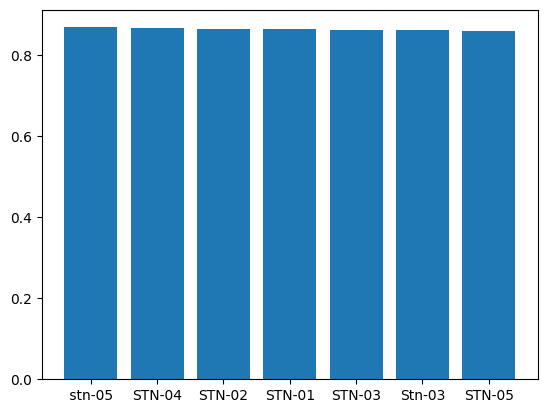

In [61]:
plt.bar(
    cycle_time["Station"],
    cycle_time["Average_Cycle_Time"]
)

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

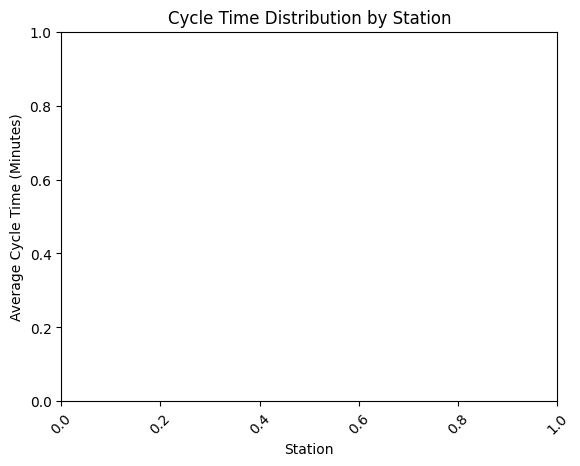

In [62]:
plt.title("Cycle Time Distribution by Station")
plt.xlabel("Station")
plt.ylabel("Average Cycle Time (Minutes)")
plt.xticks(rotation=45)

In [63]:
bottleneck = cycle_time[cycle_time["Bottleneck"] == "Yes"]

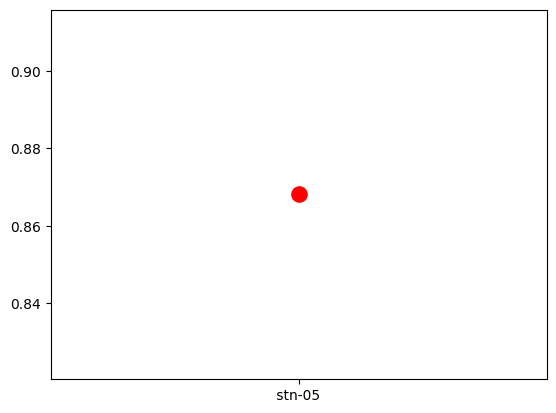

In [64]:
plt.scatter(
    bottleneck["Station"],
    bottleneck["Average_Cycle_Time"],
    color="red",
    s=120,
    label="Bottleneck"
)

C:\Users\chand\AppData\Local\Temp\ipykernel_20464\2265910356.py:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


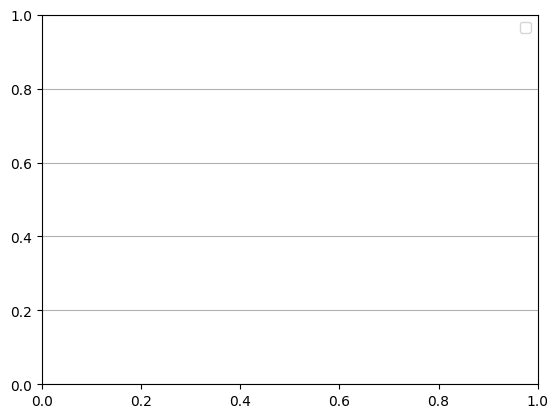


Cycle Time Analysis Completed Successfully!


In [65]:
plt.legend()
plt.grid(axis="y")

plt.show()

print("\nCycle Time Analysis Completed Successfully!")

# Test Case 6

In [66]:
sensor = pd.read_csv("sensor_readings.csv")

In [67]:
sensor["Temperature"] = (
    sensor["Temperature"]
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
)

In [68]:
sensor["Temperature"] = pd.to_numeric(
    sensor["Temperature"],
    errors="coerce"
)

In [69]:
sensor = sensor.dropna(subset=["Temperature"])

In [70]:
group_size = 5

sensor["Group"] = sensor.index // group_size

In [71]:
xbar = sensor.groupby("Group")["Temperature"].mean()

In [72]:
# R (range)
R = sensor.groupby("Group")["Temperature"].apply(
    lambda x: x.max() - x.min()
)

In [73]:
plt.figure(figsize=(12,5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

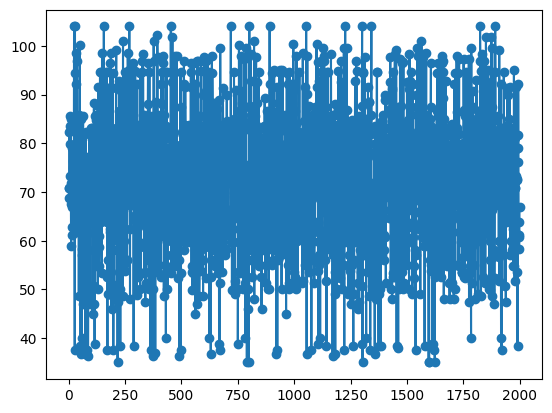

In [74]:
plt.plot(
    xbar.index,
    xbar.values,
    marker="o"
)

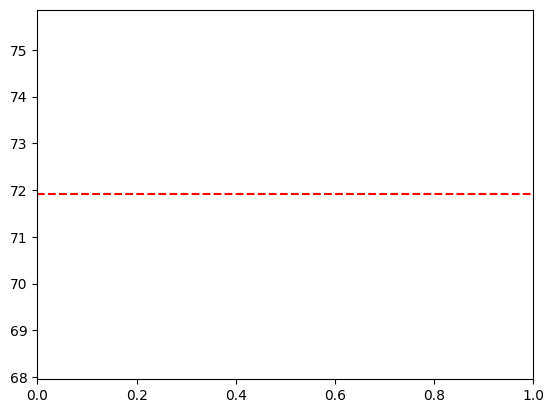

In [75]:
plt.axhline(
    xbar.mean(),
    color="red",
    linestyle="--",
    label="Center Line"
)

C:\Users\chand\AppData\Local\Temp\ipykernel_20464\944713372.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


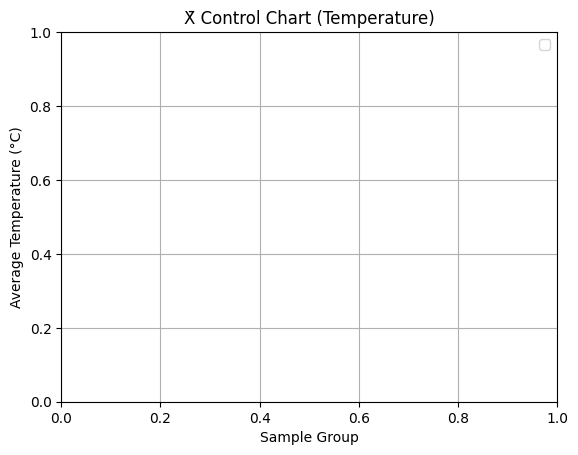

In [76]:
plt.title("X̄ Control Chart (Temperature)")
plt.xlabel("Sample Group")
plt.ylabel("Average Temperature (°C)")
plt.legend()
plt.grid(True)

plt.show()

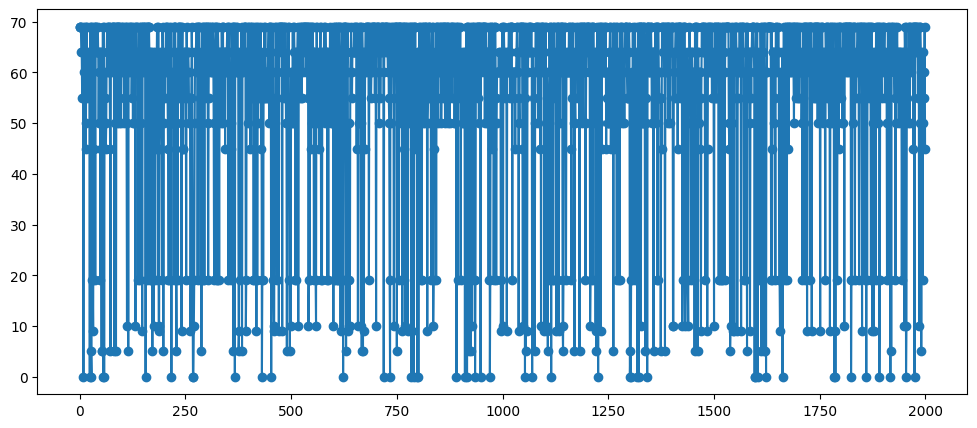

In [77]:
plt.figure(figsize=(12,5))

plt.plot(
    R.index,
    R.values,
    marker="o"
)

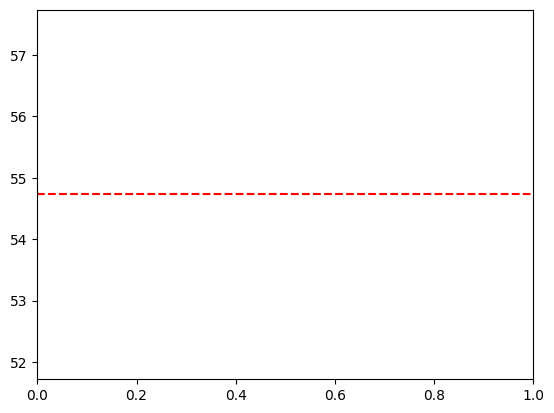

In [78]:
plt.axhline(
    R.mean(),
    color="red",
    linestyle="--",
    label="Center Line"
)

C:\Users\chand\AppData\Local\Temp\ipykernel_20464\4044002804.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


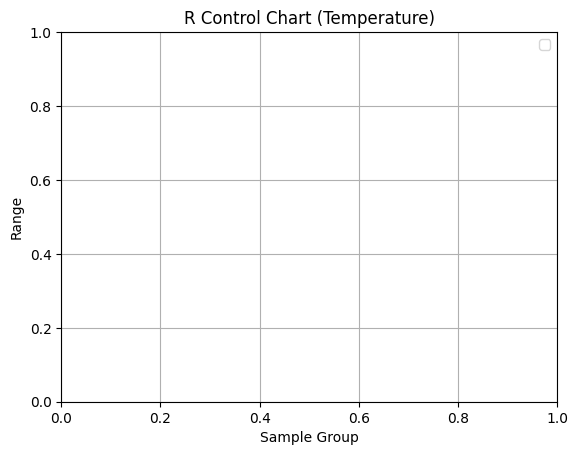

In [79]:
plt.title("R Control Chart (Temperature)")
plt.xlabel("Sample Group")
plt.ylabel("Range")
plt.legend()
plt.grid(True)

In [80]:
plt.show()


In [81]:
print("Average Temperature =", round(xbar.mean(),2))
print("Average Range =", round(R.mean(),2))

Average Temperature = 71.91
Average Range = 54.73


# Test Case 7

In [82]:
production = pd.read_csv("updated_production_events.csv")
supplier = pd.read_csv("supplier_master.csv")
bom = pd.read_csv("bom_master.csv")
warranty = pd.read_csv("warranty_claims.csv")

In [83]:
trace = production.merge(
    supplier,
    on="Supplier_Code",
    how="left"
)


In [84]:
trace = trace.merge(
    bom,
    on="Part_Number",
    how="left"
)

In [89]:
print(warranty.columns)
print(production.columns)
print(supplier.columns)
print(bom.columns)


Index(['WC1016', 'MA1AB100000000016', '2026-05-14', 'F016', 'Clutch Wear',
       '640', 'City Cars', 'Clutch Plate Replaced', 'Closed', '3'],
      dtype='object')
Index(['Event_ID', 'VIN', 'Work_Order', 'Model', 'Line', 'Station',
       'Timestamp', 'Part_Number', 'Supplier_Code', 'Operator_ID', 'Tool_ID',
       'Shift', 'Machine_ID', 'Breakdown', 'Operating_Time_Minutes',
       'Repair_Time_Minutes', 'Failure_Code', 'Planned_Time_Minutes',
       'Run_Time_Minutes', 'Ideal_Cycle_Time', 'Total_Units', 'Reject_Units',
       'Good_Units', 'Downtime_Minutes'],
      dtype='object')
Index(['Supplier_Code', 'Supplier_Name', 'City', 'State', 'Country',
       'Supplier_Type', 'Quality_Rating', 'On_Time_Delivery_%', 'PPM_Defects',
       'Contact_Email'],
      dtype='object')
Index(['Part_Number', 'Part_Name', 'Category', 'BOM_Version', 'Effective_Date',
       'Unit_Cost_USD', 'Supplier_Code', 'Status', 'Plant'],
      dtype='object')


In [90]:
warranty = pd.read_csv(
    "warranty_claims.csv",
    header=None,
    names=[
        "Claim_ID",
        "VIN",
        "Claim_Date",
        "Failure_Code",
        "Failure_Description",
        "Warranty_Cost",
        "Dealer_Name",
        "Resolution",
        "Claim_Status",
        "Days_to_Close"
    ]
)

print(warranty.head())

  Claim_ID                VIN  Claim_Date Failure_Code   Failure_Description  \
0   WC1016  MA1AB100000000016  2026-05-14         F016           Clutch Wear   
1   WC1017  MA1AB100000000017  2026-05-15         F017         Radiator Leak   
2   WC1018  MA1AB100000000018  2026-05-16         F018  Power Window Failure   
3   WC1019  MA1AB100000000019  2026-05-17         F019     ABS Warning Light   
4   WC1020  MA1AB100000000020  2026-05-18         F020           Oil Leakage   

   Warranty_Cost   Dealer_Name                 Resolution Claim_Status  \
0            640     City Cars      Clutch Plate Replaced       Closed   
1            980  Metro Motors          Radiator Replaced       Closed   
2            270    ABC Motors  Window Regulator Replaced       Closed   
3            510    Prime Auto        ABS Sensor Replaced       Closed   
4            760     City Cars            Gasket Replaced       Closed   

   Days_to_Close  
0              3  
1              4  
2              2 

In [91]:
trace = trace.merge(
    warranty,
    on="VIN",
    how="left"
)

In [93]:
print(trace.columns)

Index(['Event_ID', 'VIN', 'Work_Order', 'Model', 'Line', 'Station',
       'Timestamp', 'Part_Number', 'Supplier_Code_x', 'Operator_ID', 'Tool_ID',
       'Shift', 'Machine_ID', 'Breakdown', 'Operating_Time_Minutes',
       'Repair_Time_Minutes', 'Failure_Code_x', 'Planned_Time_Minutes',
       'Run_Time_Minutes', 'Ideal_Cycle_Time', 'Total_Units', 'Reject_Units',
       'Good_Units', 'Downtime_Minutes', 'Supplier_Name', 'City', 'State',
       'Country', 'Supplier_Type', 'Quality_Rating', 'On_Time_Delivery_%',
       'PPM_Defects', 'Contact_Email', 'Part_Name', 'Category', 'BOM_Version',
       'Effective_Date', 'Unit_Cost_USD', 'Supplier_Code_y', 'Status', 'Plant',
       'Claim_ID', 'Claim_Date', 'Failure_Code_y', 'Failure_Description',
       'Warranty_Cost', 'Dealer_Name', 'Resolution', 'Claim_Status',
       'Days_to_Close'],
      dtype='object')


In [94]:
traceability = trace[[
    "Supplier_Code_x",
    "Supplier_Name",
    "Part_Number",
    "VIN",
    "Claim_ID",
    "Failure_Code_y",
    "Warranty_Cost",
    "Claim_Status"
]]

traceability = traceability.rename(columns={
    "Supplier_Code_x": "Supplier_Code",
    "Failure_Code_y": "Failure_Code"
})

print(traceability.head())

traceability.to_csv("Traceability_Chain.csv", index=False)

  Supplier_Code      Supplier_Name Part_Number                VIN Claim_ID  \
0           NaN                NaN   eng-1001           XX1 2 3 4      NaN   
1       SUP-140  Auto Supplier 140    ENG-1379  MA1AB100000000001      NaN   
2       SUP-060   Auto Supplier 60    ENG-1111  MA1AB100000000002      NaN   
3       SUP-180  Auto Supplier 180    ENG-1332  MA1AB100000000003      NaN   
4       SUP-002    Auto Supplier 2    ENG-1445  MA1AB100000000004      NaN   

  Failure_Code  Warranty_Cost Claim_Status  
0          NaN            NaN          NaN  
1          NaN            NaN          NaN  
2          NaN            NaN          NaN  
3          NaN            NaN          NaN  
4          NaN            NaN          NaN  


In [96]:
print(traceability.head(10))


  Supplier_Code      Supplier_Name Part_Number                VIN Claim_ID  \
0           NaN                NaN   eng-1001           XX1 2 3 4      NaN   
1       SUP-140  Auto Supplier 140    ENG-1379  MA1AB100000000001      NaN   
2       SUP-060   Auto Supplier 60    ENG-1111  MA1AB100000000002      NaN   
3       SUP-180  Auto Supplier 180    ENG-1332  MA1AB100000000003      NaN   
4       SUP-002    Auto Supplier 2    ENG-1445  MA1AB100000000004      NaN   
5       SUP-196  Auto Supplier 196    ENG-1110  MA1AB100000000005      NaN   
6       SUP-089   Auto Supplier 89    ENG-1433  MA1AB100000000006      NaN   
7       SUP-142  Auto Supplier 142    ENG-1040  MA1AB100000000007      NaN   
8       SUP-012   Auto Supplier 12    ENG-1035  MA1AB100000000008      NaN   
9       SUP-098   Auto Supplier 98    ENG-1051  MA1AB100000000009      NaN   

  Failure_Code  Warranty_Cost Claim_Status  
0          NaN            NaN          NaN  
1          NaN            NaN          NaN  
2     

In [97]:
traceability.to_csv("Traceability_Chain.csv", index=False)

print("Traceability Chain Created Successfully!")

Traceability Chain Created Successfully!


# Test Case 8

In [98]:
production = pd.read_csv("updated_production_events.csv")

In [99]:
production["Alert_Time"] = pd.to_datetime(
    production["Alert_Time"],
    errors="coerce"
)

In [100]:
production["Response_Time"] = pd.to_datetime(
    production["Response_Time"],
    errors="coerce"
)

In [101]:
production["Response_Time_Minutes"] = (
    production["Response_Time"] -
    production["Alert_Time"]
).dt.total_seconds() / 60

In [102]:
production = production.dropna(subset=["Response_Time_Minutes"])

In [103]:
andon_station = (
    production.groupby("Station")
    .agg(
        Total_Alerts=("Event_ID", "count"),
        Avg_Response_Time_Minutes=("Response_Time_Minutes", "mean"),
        Min_Response_Time=("Response_Time_Minutes", "min"),
        Max_Response_Time=("Response_Time_Minutes", "max")
    )
    .reset_index()
)

In [104]:
andon_station["Avg_Response_Time_Minutes"] = (
    andon_station["Avg_Response_Time_Minutes"]
).round(2)

In [105]:
print("\nAndon Response Time by Station")
print(andon_station)


Andon Response Time by Station
    Station  Total_Alerts  Avg_Response_Time_Minutes  Min_Response_Time  \
0   stn-05            728                       4.39                1.0   
1    STN-01           700                       4.51                1.0   
2    STN-02           705                       4.41                1.0   
3    STN-03           754                       4.52                1.0   
4    STN-04           770                       4.39                1.0   
5    STN-05           668                       4.60                1.0   
6    Stn-03           725                       4.49                1.0   

   Max_Response_Time  
0                8.0  
1                8.0  
2                8.0  
3                8.0  
4                8.0  
5                8.0  
6                8.0  


In [106]:
andon_shift = (
    production.groupby("Shift")
    .agg(
        Total_Alerts=("Event_ID", "count"),
        Avg_Response_Time_Minutes=("Response_Time_Minutes", "mean")
    )
    .reset_index()
)

In [107]:
andon_shift["Avg_Response_Time_Minutes"] = (
    andon_shift["Avg_Response_Time_Minutes"]
).round(2)

In [108]:
print("\nAndon Response Time by Shift")
print(andon_shift)


Andon Response Time by Shift
  Shift  Total_Alerts  Avg_Response_Time_Minutes
0     A          1269                       4.45
1     B          1286                       4.52
2     C          1242                       4.53


In [109]:
andon_station.to_csv("Andon_Response_By_Station.csv", index=False)
andon_shift.to_csv("Andon_Response_By_Shift.csv", index=False)

print("\nAndon Alert Response Time Metrics Completed Successfully!")


Andon Alert Response Time Metrics Completed Successfully!


# Test Case 9

In [111]:
production = pd.read_csv("updated_production_events.csv")
quality = pd.read_csv("quality_inspection.csv")

In [112]:
warranty = pd.read_csv(
    "warranty_claims.csv",
    header=None,
    names=[
        "Claim_ID",
        "VIN",
        "Claim_Date",
        "Failure_Code",
        "Failure_Description",
        "Warranty_Cost",
        "Dealer_Name",
        "Resolution",
        "Claim_Status",
        "Days_to_Close"
    ]
)


In [113]:
SCRAP_COST_PER_UNIT = 500

scrap_units = production["Reject_Units"].sum()

scrap_cost = scrap_units * SCRAP_COST_PER_UNIT

In [114]:
REWORK_COST_PER_UNIT = 200

rework_units = (
    quality["Rework_Flag"]
    .astype(str)
    .str.upper()
    .eq("YES")
    .sum()
)

rework_cost = rework_units * REWORK_COST_PER_UNIT

In [115]:
warranty["Warranty_Cost"] = pd.to_numeric(
    warranty["Warranty_Cost"],
    errors="coerce"
)

warranty_cost = warranty["Warranty_Cost"].sum()

In [116]:
copq = scrap_cost + rework_cost + warranty_cost

print("========== COPQ ==========")
print("Scrap Units :", scrap_units)
print("Scrap Cost  : ₹", scrap_cost)

print("\nRework Units :", rework_units)
print("Rework Cost  : ₹", rework_cost)

print("\nWarranty Cost : ₹", warranty_cost)

print("\nTotal COPQ : ₹", copq)

========== COPQ ==========
Scrap Units : 37957
Scrap Cost  : ₹ 18978500

Rework Units : 0
Rework Cost  : ₹ 0

Warranty Cost : ₹ 68490

Total COPQ : ₹ 19046990


In [117]:
copq_summary = pd.DataFrame({
    "Metric": [
        "Scrap Cost",
        "Rework Cost",
        "Warranty Cost",
        "Total COPQ"
    ],
    "Amount": [
        scrap_cost,
        rework_cost,
        warranty_cost,
        copq
    ]
})

copq_summary.to_csv("COPQ_Summary.csv", index=False)

print("\nCOPQ calculation completed successfully!")


COPQ calculation completed successfully!


# Test Case 10

In [118]:
production = pd.read_csv("updated_production_events.csv")


In [119]:
production["Throughput"] = (
    production["Total_Units"] /
    production["Run_Time_Minutes"]
).round(2)

In [120]:
production["Cycle_Time"] = (
    production["Run_Time_Minutes"] /
    production["Total_Units"]
).round(2)

In [121]:
production["WIP"] = (
    production["Throughput"] *
    production["Cycle_Time"]
).round(2)

In [122]:
summary = (
    production.groupby("Station")
    .agg(
        Average_Throughput=("Throughput", "mean"),
        Average_Cycle_Time=("Cycle_Time", "mean"),
        Average_WIP=("WIP", "mean")
    )
    .reset_index()
)

summary = summary.round(2)

print(summary)

    Station  Average_Throughput  Average_Cycle_Time  Average_WIP
0   stn-05                 1.16                0.87          1.0
1    STN-01                1.17                0.86          1.0
2    STN-02                1.17                0.86          1.0
3    STN-03                1.17                0.86          1.0
4    STN-04                1.16                0.87          1.0
5    STN-05                1.17                0.86          1.0
6    Stn-03                1.17                0.86          1.0


In [123]:
summary.to_csv("Throughput_WIP_Diagnostics.csv", index=False)

<BarContainer object of 7 artists>

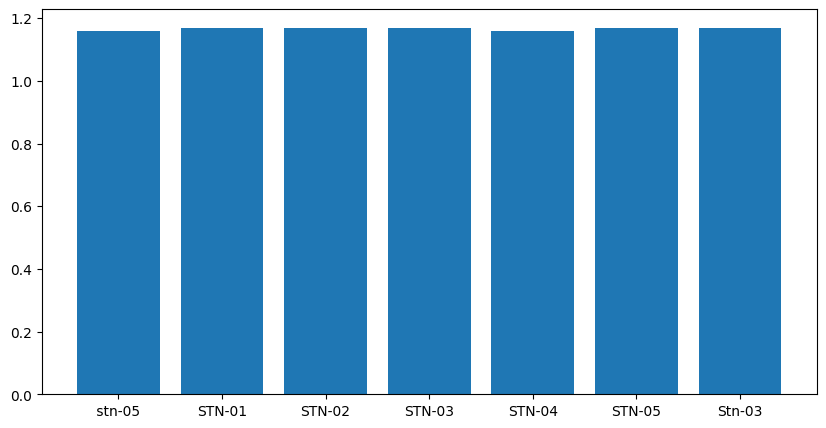

In [124]:
plt.figure(figsize=(10,5))

plt.bar(
    summary["Station"],
    summary["Average_Throughput"],
    label="Throughput"
)

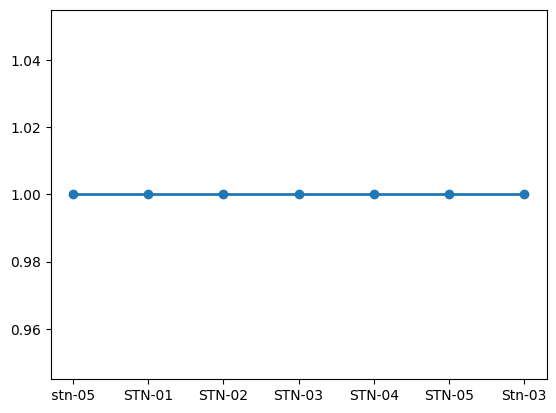

In [125]:
plt.plot(
    summary["Station"],
    summary["Average_WIP"],
    marker="o",
    linewidth=2,
    label="WIP"
)

C:\Users\chand\AppData\Local\Temp\ipykernel_20464\805931334.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


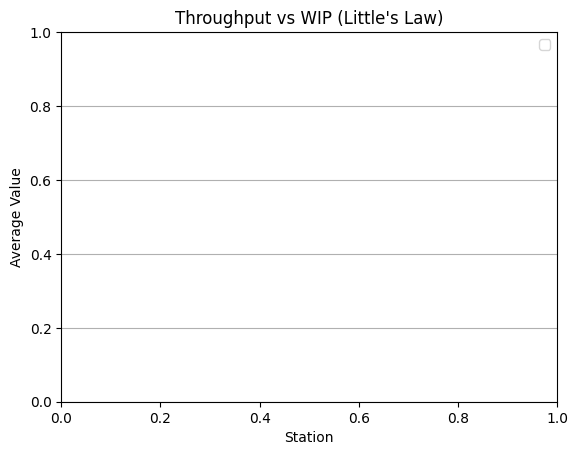


Little's Law Diagnostics Completed Successfully!


In [126]:
plt.title("Throughput vs WIP (Little's Law)")
plt.xlabel("Station")
plt.ylabel("Average Value")
plt.legend()
plt.grid(axis="y")

plt.show()

print("\nLittle's Law Diagnostics Completed Successfully!")